# Read in the Data

Read in the CSV as a dataframe and index with datetime year-month-date fomrat. The data is from free course Macroeconomic Forecasting on EdX. 

In [43]:
import pandas as pd
from matplotlib import pyplot 

#Read in the data
df = pd.read_csv("macroforecastingdata.csv")
df_usa_cy =pd.read_csv("usa_cy.csv")

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from datetime import date

#Set the index column
indexed_df=df.set_index('dateid01')
indexed_df.index=pd.to_datetime(indexed_df.index, format="%Y/%m/%d")


indexed_df_usa_cy=df_usa_cy.set_index('dateid01')
indexed_df_usa_cy.index=pd.to_datetime(indexed_df_usa_cy.index, format="%Y/%m/%d")
print(indexed_df)
print(indexed_df.columns.tolist())
print(indexed_df_usa_cy.columns.tolist())

                             dateid    assets  assets_fin  \
dateid01                                                    
1945-01-01  1945-03-31 23:59:59.999       NaN         NaN   
1945-04-01  1945-06-30 23:59:59.999       NaN         NaN   
1945-07-01  1945-09-30 23:59:59.999       NaN         NaN   
1945-10-01  1945-12-31 23:59:59.999  797839.9    608512.9   
1946-01-01  1946-03-31 23:59:59.999       NaN         NaN   
...                             ...       ...         ...   
2014-10-01  2014-12-31 23:59:59.999       NaN         NaN   
2015-01-01  2015-03-31 23:59:59.999       NaN         NaN   
2015-04-01  2015-06-30 23:59:59.999       NaN         NaN   
2015-07-01  2015-09-30 23:59:59.999       NaN         NaN   
2015-10-01  2015-12-31 23:59:59.999       NaN         NaN   

            assets_nonfinancial  c_deflator  consumer_sentiment      cpi  \
dateid01                                                                   
1945-01-01                  NaN         NaN           

Add the log of key macroeconomic variables and put the exogenous variable into the same dataframe. 

In [45]:
import numpy as np

#Create log variables
indexed_df["log rc"]=np.log(indexed_df["rc"])
indexed_df["log rdy"]=np.log(indexed_df["rdy"])
indexed_df['rnw']=indexed_df_usa_cy["rnw"]
indexed_df['log rnw']=np.log(indexed_df["rnw"])

#Add exogenous variables to the dataframe
indexed_df['unemployment']=indexed_df_usa_cy["unemp"]
indexed_df['consumer sentiment']=indexed_df_usa_cy["consumer_sentiment"]

#Show new dataframe
print(indexed_df)

#Show what all the columns are in our new dataframe
print(indexed_df.columns.tolist())

                             dateid    assets  assets_fin  \
dateid01                                                    
1945-01-01  1945-03-31 23:59:59.999       NaN         NaN   
1945-04-01  1945-06-30 23:59:59.999       NaN         NaN   
1945-07-01  1945-09-30 23:59:59.999       NaN         NaN   
1945-10-01  1945-12-31 23:59:59.999  797839.9    608512.9   
1946-01-01  1946-03-31 23:59:59.999       NaN         NaN   
...                             ...       ...         ...   
2014-10-01  2014-12-31 23:59:59.999       NaN         NaN   
2015-01-01  2015-03-31 23:59:59.999       NaN         NaN   
2015-04-01  2015-06-30 23:59:59.999       NaN         NaN   
2015-07-01  2015-09-30 23:59:59.999       NaN         NaN   
2015-10-01  2015-12-31 23:59:59.999       NaN         NaN   

            assets_nonfinancial  c_deflator  consumer_sentiment      cpi  \
dateid01                                                                   
1945-01-01                  NaN         NaN           

In [46]:
filtered_df=indexed_df.dropna(subset=['log rc', 'log rnw',])


In [47]:
from statsmodels.tsa.stattools import adfuller
print(indexed_df)

filtered_df_1976 = filtered_df[filtered_df.index >= '1976-01-01']

log_rc_list = filtered_df_1976['log rc'].tolist()
log_rdy_list = filtered_df_1976['log rdy'].tolist()
log_rnw_list = filtered_df_1976['log rnw'].tolist()


result1=adfuller(log_rc_list,autolag='AIC')

result2=adfuller(log_rdy_list,autolag='AIC')

result3=adfuller(log_rnw_list,autolag='AIC')

print("log rc results:", result1)
print("log rdy results:", result2)
print("log rnw results:", result3)

                             dateid    assets  assets_fin  \
dateid01                                                    
1945-01-01  1945-03-31 23:59:59.999       NaN         NaN   
1945-04-01  1945-06-30 23:59:59.999       NaN         NaN   
1945-07-01  1945-09-30 23:59:59.999       NaN         NaN   
1945-10-01  1945-12-31 23:59:59.999  797839.9    608512.9   
1946-01-01  1946-03-31 23:59:59.999       NaN         NaN   
...                             ...       ...         ...   
2014-10-01  2014-12-31 23:59:59.999       NaN         NaN   
2015-01-01  2015-03-31 23:59:59.999       NaN         NaN   
2015-04-01  2015-06-30 23:59:59.999       NaN         NaN   
2015-07-01  2015-09-30 23:59:59.999       NaN         NaN   
2015-10-01  2015-12-31 23:59:59.999       NaN         NaN   

            assets_nonfinancial  c_deflator  consumer_sentiment      cpi  \
dateid01                                                                   
1945-01-01                  NaN         NaN           

Log RC: Test statistic = -0.985, p-value = 0.759

Not stationary (p-value > 0.05, test statistic > critical values)

Log RDY: Test statistic = -1.695, p-value = 0.437

Not stationary (p-value > 0.05, test statistic > critical values)

Log RNW: Test statistic = -0.754, p-value = 0.832

Not stationary (p-value > 0.05, test statistic > critical values)

In [48]:




df_3 = pd.DataFrame({
    'log(rc)': log_rc_list,
    'log(rdy)': log_rdy_list,
    'log(rnw)': log_rnw_list,
}, index=filtered_df_1976.index)

print(df_3)

             log(rc)  log(rdy)   log(rnw)
dateid01                                 
1976-01-01  8.171854  8.320424  16.762529
1976-04-01  8.180993  8.325597  16.781955
1976-07-01  8.191546  8.332934  16.792481
1976-10-01  8.204535  8.338880  16.799313
1977-01-01  8.215899  8.338569  16.796359
...              ...       ...        ...
2013-07-01  9.279241  9.367848  18.080066
2013-10-01  9.288356  9.368344  18.107855
2014-01-01  9.291395  9.376710  18.113577
2014-04-01  9.297673  9.384327  18.135219
2014-07-01  9.305605  9.390184  18.130669

[155 rows x 3 columns]


In [49]:

unemployment = filtered_df_1976['unemployment'].tolist()
consumer_sentiment = filtered_df_1976['consumer sentiment'].tolist()
gov_transfers=filtered_df_1976['gov_transfers'].tolist()
y_deflator=filtered_df_1976['y_deflator'].tolist()
interest_payments=filtered_df_1976['interest_payments'].tolist()

df_4=pd.DataFrame({
    'log(rc)': log_rc_list,
    'log(rdy)': log_rdy_list,
    'log(rnw)': log_rnw_list,
    'unemployment':unemployment,
    'consumer_sentiment':consumer_sentiment,
}, index=filtered_df_1976.index)


print(df_4)


    

             log(rc)  log(rdy)   log(rnw)  unemployment  consumer_sentiment
dateid01                                                                   
1976-01-01  8.171854  8.320424  16.762529           7.6                84.6
1976-04-01  8.180993  8.325597  16.781955           7.6                83.3
1976-07-01  8.191546  8.332934  16.792481           7.6                89.7
1976-10-01  8.204535  8.338880  16.799313           7.8                87.0
1977-01-01  8.215899  8.338569  16.796359           7.4                87.1
...              ...       ...        ...           ...                 ...
2013-07-01  9.279241  9.367848  18.080066           7.2                77.5
2013-10-01  9.288356  9.368344  18.107855           6.7                82.5
2014-01-01  9.291395  9.376710  18.113577           6.6                80.0
2014-04-01  9.297673  9.384327  18.135219           6.1                84.1
2014-07-01  9.305605  9.390184  18.130669           5.9                86.4

[155 rows x

                             dateid      assets  assets_fin  \
dateid01                                                      
1976-01-01  1976-03-31 23:59:59.999   6774772.0   4439762.0   
1976-04-01  1976-06-30 23:59:59.999   6976288.1   4555992.1   
1976-07-01  1976-09-30 23:59:59.999   7112487.5   4641046.5   
1976-10-01  1976-12-31 23:59:59.999   7303654.8   4760545.8   
1977-01-01  1977-03-31 23:59:59.999   7431399.5   4801388.5   
...                             ...         ...         ...   
2013-07-01  2013-09-30 23:59:59.999  89943232.0  62806533.0   
2013-10-01  2013-12-31 23:59:59.999  92659740.2  64986161.2   
2014-01-01  2014-03-31 23:59:59.999  93864946.6  65746107.6   
2014-04-01  2014-06-30 23:59:59.999  95430244.7  67072061.7   
2014-07-01  2014-09-30 23:59:59.999  95410006.1  66756576.1   

            assets_nonfinancial  c_deflator  consumer_sentiment      cpi  \
dateid01                                                                   
1976-01-01            233501

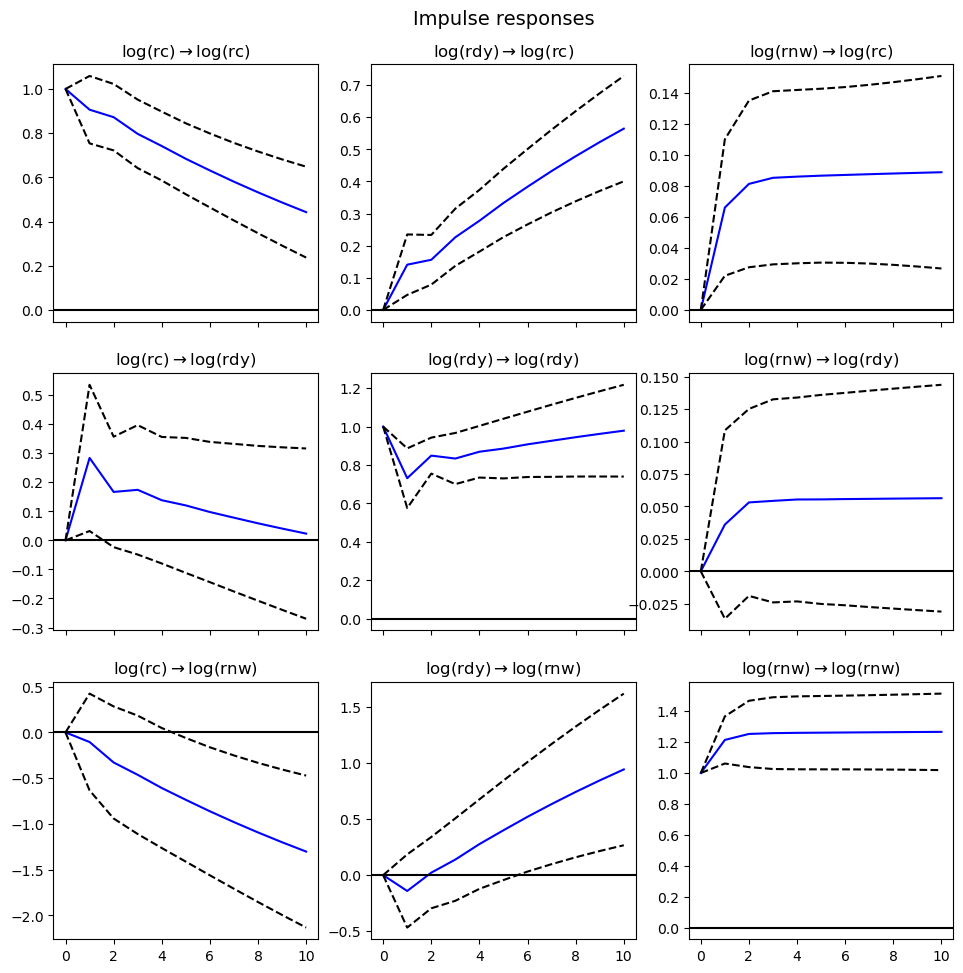

In [50]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import VECM


print(filtered_df_1976)

# 1. Prepare the data
# Endogenous variables: log(rc), log(rnw), log(rdy)
endog = df_4[['log(rc)', 'log(rdy)', 'log(rnw)']]


# Exogenous variables: consumer_sentiment, structural_break, unemployment
exog = df_4[['consumer_sentiment', 'unemployment']]

# 2. Set up the VECM model with k_ar_diff=1 (lag of 1) and coint_rank=1 (1 cointegrating vector)
# Note: k_ar_diff is the lag order of the differenced VAR, so 1 means 2 lags in levels
model = VECM(endog=endog, exog=exog, k_ar_diff=1, coint_rank=1, 
             deterministic="ci", seasons=0)

# 3. Fit the model
fitted_model = model.fit()

# 4. Print the results
print(fitted_model.summary())

# 5. Access components differently
print("Cointegrating Vector:")
print(fitted_model.beta)

print("\nLoading Matrix (Adjustment Coefficients):")
print(fitted_model.alpha)


# The exogenous variable coefficients will be included in the params
# You can also look at the individual equations:
print("\nCoefficients for Each Equation:")

# 6. For impulse response functions
try:
    irf = fitted_model.irf(10)  # 10 periods ahead
    print("\nImpulse Response Functions:")
    print(irf)
    # Try to plot them if possible
    try:
        irf.plot(orth=False)
    except:
        print("Could not plot IRFs, but they were calculated")
except AttributeError:
    print("\nIRF functionality not available in this version of statsmodels")
    

✅ Using columns: ['log(rc)', 'log(rdy)', 'log(rnw)']
📅 Training ends: 2004-03-31
📊 Training: 113 observations
📊 Testing: 41 observations
📊 Test period: 2004-07-01 00:00:00 to 2014-07-01 00:00:00
🔧 Fitting VECM model...
✅ VECM fitted successfully!
🚀 Generating 41-step forecast...
✅ Forecast generated!

📈 FORECAST ACCURACY:
log(rc):
  RMSE: 0.126417
  MAE:  0.101333
  MAPE: 1.10%

log(rdy):
  RMSE: 0.101014
  MAE:  0.081673
  MAPE: 0.87%

log(rnw):
  RMSE: 0.191278
  MAE:  0.167696
  MAPE: 0.93%



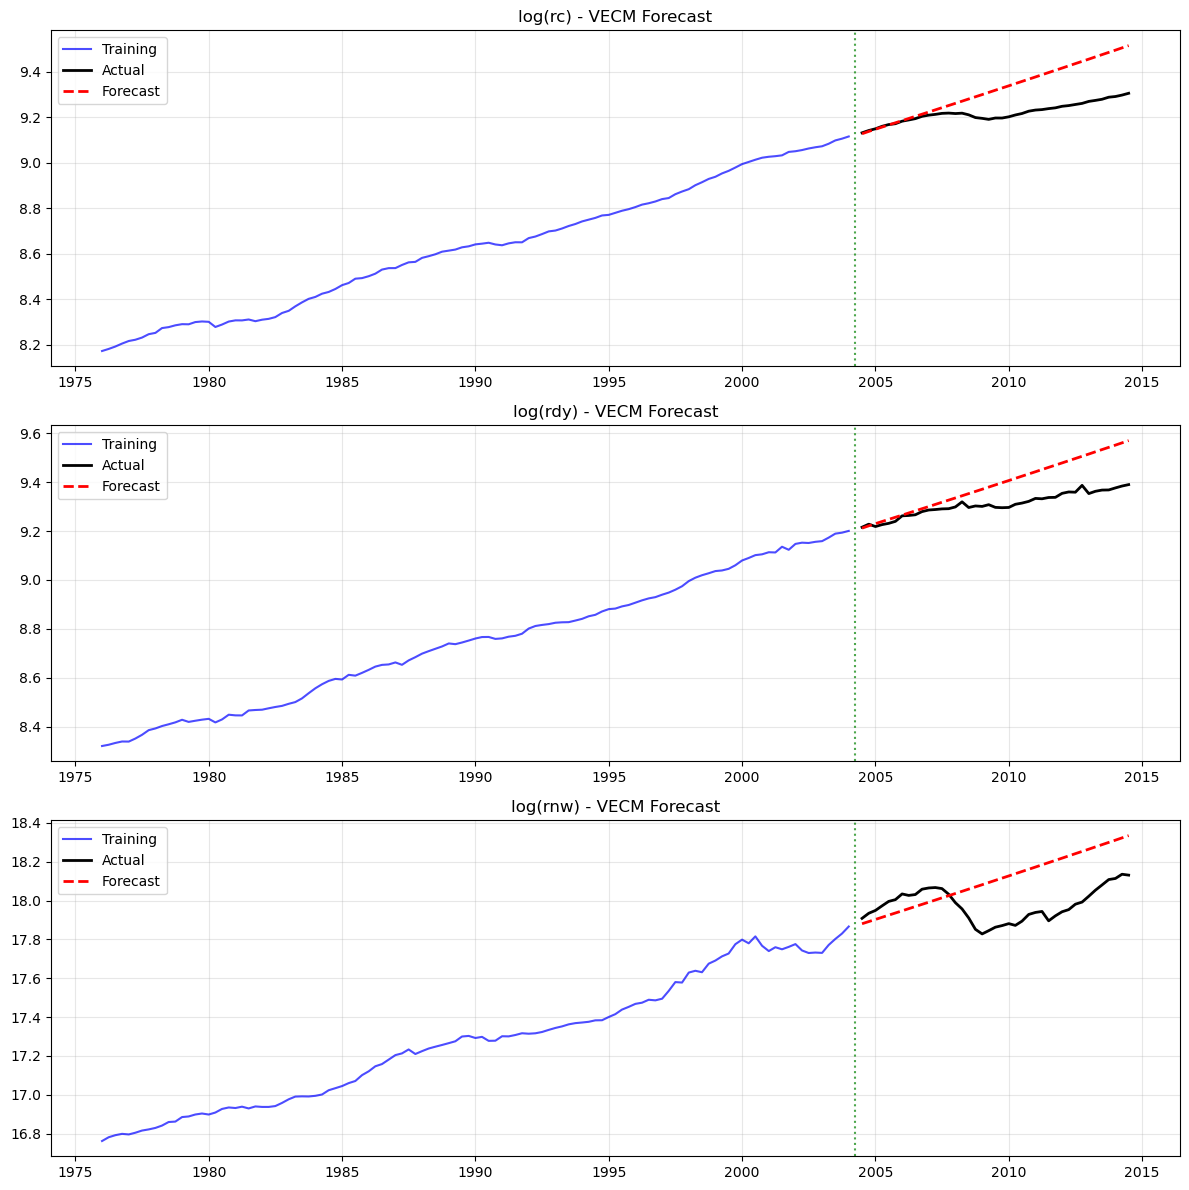

🎉 Done! Check the 'results' dictionary for all outputs.
{'forecast':              log(rc)  log(rdy)   log(rnw)
dateid01                                 
2004-07-01  9.127561  9.211995  17.880547
2004-10-01  9.137848  9.221501  17.891691
2005-01-01  9.147446  9.230396  17.902685
2005-04-01  9.156899  9.239129  17.913699
2005-07-01  9.166329  9.247843  17.924748
2005-10-01  9.175769  9.256563  17.935817
2006-01-01  9.185222  9.265296  17.946904
2006-04-01  9.194689  9.274043  17.958008
2006-07-01  9.204171  9.282803  17.969129
2006-10-01  9.213667  9.291576  17.980266
2007-01-01  9.223177  9.300362  17.991421
2007-04-01  9.232703  9.309162  18.002593
2007-07-01  9.242242  9.317975  18.013782
2007-10-01  9.251796  9.326802  18.024987
2008-01-01  9.261365  9.335642  18.036210
2008-04-01  9.270948  9.344495  18.047450
2008-07-01  9.280546  9.353362  18.058707
2008-10-01  9.290159  9.362243  18.069981
2009-01-01  9.299786  9.371137  18.081273
2009-04-01  9.309428  9.380044  18.092581
2009-07

In [59]:
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

def simple_vecm_forecast(data, train_end_date, coint_rank=1, k_ar_diff=1):
    """
    Simple VECM forecasting function - just specify when training should end!
    
    Parameters:
    -----------
    data : pandas DataFrame
        Your time series data 
    train_end_date : str
        End date for training (e.g., '2007-12-31')
        Everything after this date will be used for testing/forecasting
    coint_rank : int, default=1
        Number of cointegrating relationships
    k_ar_diff : int, default=1
        Number of lags in differences
        
    Returns:
    --------
    Dictionary with forecast results and metrics
    """
    
    # Check if train_end_date is provided
    if train_end_date is None:
        print("❌ ERROR: You must specify train_end_date!")
        print("📝 Example: simple_vecm_forecast(data, train_end_date='2007-12-31')")
        return None
    
    # Use these columns - change if your columns are different
    endog_vars = ['log(rc)', 'log(rdy)', 'log(rnw)']
    
    # Quick column check
    missing_cols = [col for col in endog_vars if col not in data.columns]
    if missing_cols:
        print(f"❌ ERROR: Missing columns: {missing_cols}")
        print(f"📋 Your columns: {list(data.columns)}")
        return None
    
    print(f"✅ Using columns: {endog_vars}")
    print(f"📅 Training ends: {train_end_date}")
    
    # Make sure index is datetime
    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)
    
    # Split the data
    train_data = data[endog_vars].loc[:train_end_date]
    test_data = data[endog_vars].loc[train_end_date:].iloc[1:]  # Skip overlap
    
    # Clean test data (remove NaN)
    test_data_clean = test_data.dropna()
    
    if len(test_data_clean) == 0:
        print("❌ ERROR: No valid test data!")
        return None
    
    print(f"📊 Training: {len(train_data)} observations")
    print(f"📊 Testing: {len(test_data_clean)} observations")
    print(f"📊 Test period: {test_data_clean.index[0]} to {test_data_clean.index[-1]}")
    
    # Fit VECM model
    print("🔧 Fitting VECM model...")
    try:
        vecm_model = VECM(train_data.values, 
                         k_ar_diff=k_ar_diff,
                         coint_rank=coint_rank)
        vecm_fitted = vecm_model.fit()
        print("✅ VECM fitted successfully!")
    except Exception as e:
        print(f"❌ VECM fitting failed: {e}")
        return None
    
    # Generate forecast
    steps_ahead = len(test_data_clean)
    print(f"🚀 Generating {steps_ahead}-step forecast...")
    
    try:
        # Try different forecasting methods
        if hasattr(vecm_fitted, 'forecast'):
            forecast = vecm_fitted.forecast(steps=steps_ahead)
        elif hasattr(vecm_fitted, 'predict'):
            forecast = vecm_fitted.predict(steps=steps_ahead)
        else:
            print("❌ No forecasting method available")
            return None
        
        print("✅ Forecast generated!")
        
    except Exception as e:
        print(f"❌ Forecasting failed: {e}")
        return None
    
    # Create results dataframes
    forecast_df = pd.DataFrame(forecast,
                              index=test_data_clean.index,
                              columns=endog_vars)
    
    actual_df = test_data_clean.copy()
    
    # Calculate metrics
    print("\n📈 FORECAST ACCURACY:")
    print("=" * 40)
    
    metrics = {}
    for var in endog_vars:
        actual_vals = actual_df[var].values
        forecast_vals = forecast_df[var].values
        
        rmse = np.sqrt(mean_squared_error(actual_vals, forecast_vals))
        mae = mean_absolute_error(actual_vals, forecast_vals)
        mape = mean_absolute_percentage_error(actual_vals, forecast_vals) * 100
        
        metrics[var] = {
            'RMSE': rmse,
            'MAE': mae, 
            'MAPE': mape
        }
        
        print(f"{var}:")
        print(f"  RMSE: {rmse:.6f}")
        print(f"  MAE:  {mae:.6f}")
        print(f"  MAPE: {mape:.2f}%")
        print()
    
    # Simple plot
    fig, axes = plt.subplots(len(endog_vars), 1, figsize=(12, 4*len(endog_vars)))
    if len(endog_vars) == 1:
        axes = [axes]
    
    for i, var in enumerate(endog_vars):
        # Plot training data
        axes[i].plot(train_data.index, train_data[var], 
                    label='Training', color='blue', alpha=0.7)
        
        # Plot actual test data
        axes[i].plot(actual_df.index, actual_df[var], 
                    label='Actual', color='black', linewidth=2)
        
        # Plot forecast
        axes[i].plot(forecast_df.index, forecast_df[var], 
                    label='Forecast', color='red', linestyle='--', linewidth=2)
        
        axes[i].set_title(f'{var} - VECM Forecast')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add vertical line at train/test split
        axes[i].axvline(x=pd.to_datetime(train_end_date), 
                       color='green', linestyle=':', alpha=0.7, 
                       label='Train/Test Split')
    
    plt.tight_layout()
    plt.show()
    
    # Return everything
    results = {
        'forecast': forecast_df,
        'actual': actual_df,
        'metrics': metrics,
        'vecm_model': vecm_fitted,
        'train_end_date': train_end_date,
        'test_period': f"{test_data_clean.index[0]} to {test_data_clean.index[-1]}"
    }
    
    print("🎉 Done! Check the 'results' dictionary for all outputs.")
    return results
results = simple_vecm_forecast(df_4, train_end_date='2004-03-31')
print(results)

In [60]:
print(df_4)
print(results)

             log(rc)  log(rdy)   log(rnw)  unemployment  consumer_sentiment
dateid01                                                                   
1976-01-01  8.171854  8.320424  16.762529           7.6                84.6
1976-04-01  8.180993  8.325597  16.781955           7.6                83.3
1976-07-01  8.191546  8.332934  16.792481           7.6                89.7
1976-10-01  8.204535  8.338880  16.799313           7.8                87.0
1977-01-01  8.215899  8.338569  16.796359           7.4                87.1
...              ...       ...        ...           ...                 ...
2013-07-01  9.279241  9.367848  18.080066           7.2                77.5
2013-10-01  9.288356  9.368344  18.107855           6.7                82.5
2014-01-01  9.291395  9.376710  18.113577           6.6                80.0
2014-04-01  9.297673  9.384327  18.135219           6.1                84.1
2014-07-01  9.305605  9.390184  18.130669           5.9                86.4

[155 rows x

In [61]:
import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

def simple_vecm_forecast_static(data, train_end_date, coint_rank=1, k_ar_diff=1):
    """
    STATIC VECM forecasting - uses actual observed lagged values at each step
    """
    
    if train_end_date is None:
        print("❌ ERROR: You must specify train_end_date!")
        return None
    
    endog_vars = ['log(rc)', 'log(rdy)', 'log(rnw)']
    
    missing_cols = [col for col in endog_vars if col not in data.columns]
    if missing_cols:
        print(f"❌ ERROR: Missing columns: {missing_cols}")
        return None
    
    print(f"✅ Using columns: {endog_vars}")
    print(f"📅 Training ends: {train_end_date}")
    
    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)
    
    train_data = data[endog_vars].loc[:train_end_date]
    test_data = data[endog_vars].loc[train_end_date:].iloc[1:]
    test_data_clean = test_data.dropna()
    
    if len(test_data_clean) == 0:
        print("❌ ERROR: No valid test data!")
        return None
    
    print(f"📊 Training: {len(train_data)} observations")
    print(f"📊 Testing: {len(test_data_clean)} observations")
    print(f"📊 Test period: {test_data_clean.index[0]} to {test_data_clean.index[-1]}")
    
    print("🔧 Fitting initial VECM model...")
    try:
        vecm_model = VECM(train_data.values, 
                         k_ar_diff=k_ar_diff,
                         coint_rank=coint_rank)
        vecm_fitted = vecm_model.fit()
        print("✅ VECM fitted successfully!")
    except Exception as e:
        print(f"❌ VECM fitting failed: {e}")
        return None
    
    steps_ahead = len(test_data_clean)
    print(f"🚀 Generating {steps_ahead}-step STATIC forecast...")
    print("   (This refits the model at each step - may take a while)")
    
    try:
        forecast_list = []
        
        for i in range(steps_ahead):
            if i == 0:
                data_for_forecast = train_data
            else:
                data_for_forecast = pd.concat([train_data, test_data_clean.iloc[:i]])
            
            temp_model = VECM(data_for_forecast.values, 
                             k_ar_diff=k_ar_diff,
                             coint_rank=coint_rank)
            temp_fitted = temp_model.fit()
            
            # Use predict method with steps=1
            one_step_forecast = temp_fitted.predict(steps=1)
            forecast_list.append(one_step_forecast[0])
            
            if (i + 1) % 10 == 0:
                print(f"  Completed {i + 1}/{steps_ahead} forecasts...")
        
        forecast = np.array(forecast_list)
        print("✅ Static forecast generated!")
        
    except Exception as e:
        print(f"❌ Forecasting failed: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    forecast_df = pd.DataFrame(forecast,
                              index=test_data_clean.index,
                              columns=endog_vars)
    
    actual_df = test_data_clean.copy()
    
    print("\n📈 FORECAST ACCURACY (STATIC):")
    print("=" * 40)
    
    metrics = {}
    for var in endog_vars:
        actual_vals = actual_df[var].values
        forecast_vals = forecast_df[var].values
        
        rmse = np.sqrt(mean_squared_error(actual_vals, forecast_vals))
        mae = mean_absolute_error(actual_vals, forecast_vals)
        mape = mean_absolute_percentage_error(actual_vals, forecast_vals) * 100
        
        metrics[var] = {
            'RMSE': rmse,
            'MAE': mae, 
            'MAPE': mape
        }
        
        print(f"{var}:")
        print(f"  RMSE: {rmse:.6f}")
        print(f"  MAE:  {mae:.6f}")
        print(f"  MAPE: {mape:.2f}%")
        print()
    
    fig, axes = plt.subplots(len(endog_vars), 1, figsize=(12, 4*len(endog_vars)))
    if len(endog_vars) == 1:
        axes = [axes]
    
    for i, var in enumerate(endog_vars):
        axes[i].plot(train_data.index, train_data[var], 
                    label='Training', color='blue', alpha=0.7)
        axes[i].plot(actual_df.index, actual_df[var], 
                    label='Actual', color='black', linewidth=2)
        axes[i].plot(forecast_df.index, forecast_df[var], 
                    label='Static Forecast', color='green', linestyle='--', linewidth=2)
        
        axes[i].set_title(f'{var} - VECM Static Forecast')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].axvline(x=pd.to_datetime(train_end_date), 
                       color='purple', linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    results = {
        'forecast': forecast_df,
        'actual': actual_df,
        'metrics': metrics,
        'vecm_model': vecm_fitted,
        'train_end_date': train_end_date,
        'test_period': f"{test_data_clean.index[0]} to {test_data_clean.index[-1]}"
    }
    
    print("🎉 Done! Check the 'results' dictionary for all outputs.")
    return results

✅ Using columns: ['log(rc)', 'log(rdy)', 'log(rnw)']
📅 Training ends: 2004-03-31
📊 Training: 113 observations
📊 Testing: 41 observations
📊 Test period: 2004-07-01 00:00:00 to 2014-07-01 00:00:00
🔧 Fitting initial VECM model...
✅ VECM fitted successfully!
🚀 Generating 41-step STATIC forecast...
   (This refits the model at each step - may take a while)
  Completed 10/41 forecasts...
  Completed 20/41 forecasts...
  Completed 30/41 forecasts...
  Completed 40/41 forecasts...
✅ Static forecast generated!

📈 FORECAST ACCURACY (STATIC):
log(rc):
  RMSE: 0.004288
  MAE:  0.003377
  MAPE: 0.04%

log(rdy):
  RMSE: 0.010341
  MAE:  0.006930
  MAPE: 0.07%

log(rnw):
  RMSE: 0.022631
  MAE:  0.017668
  MAPE: 0.10%



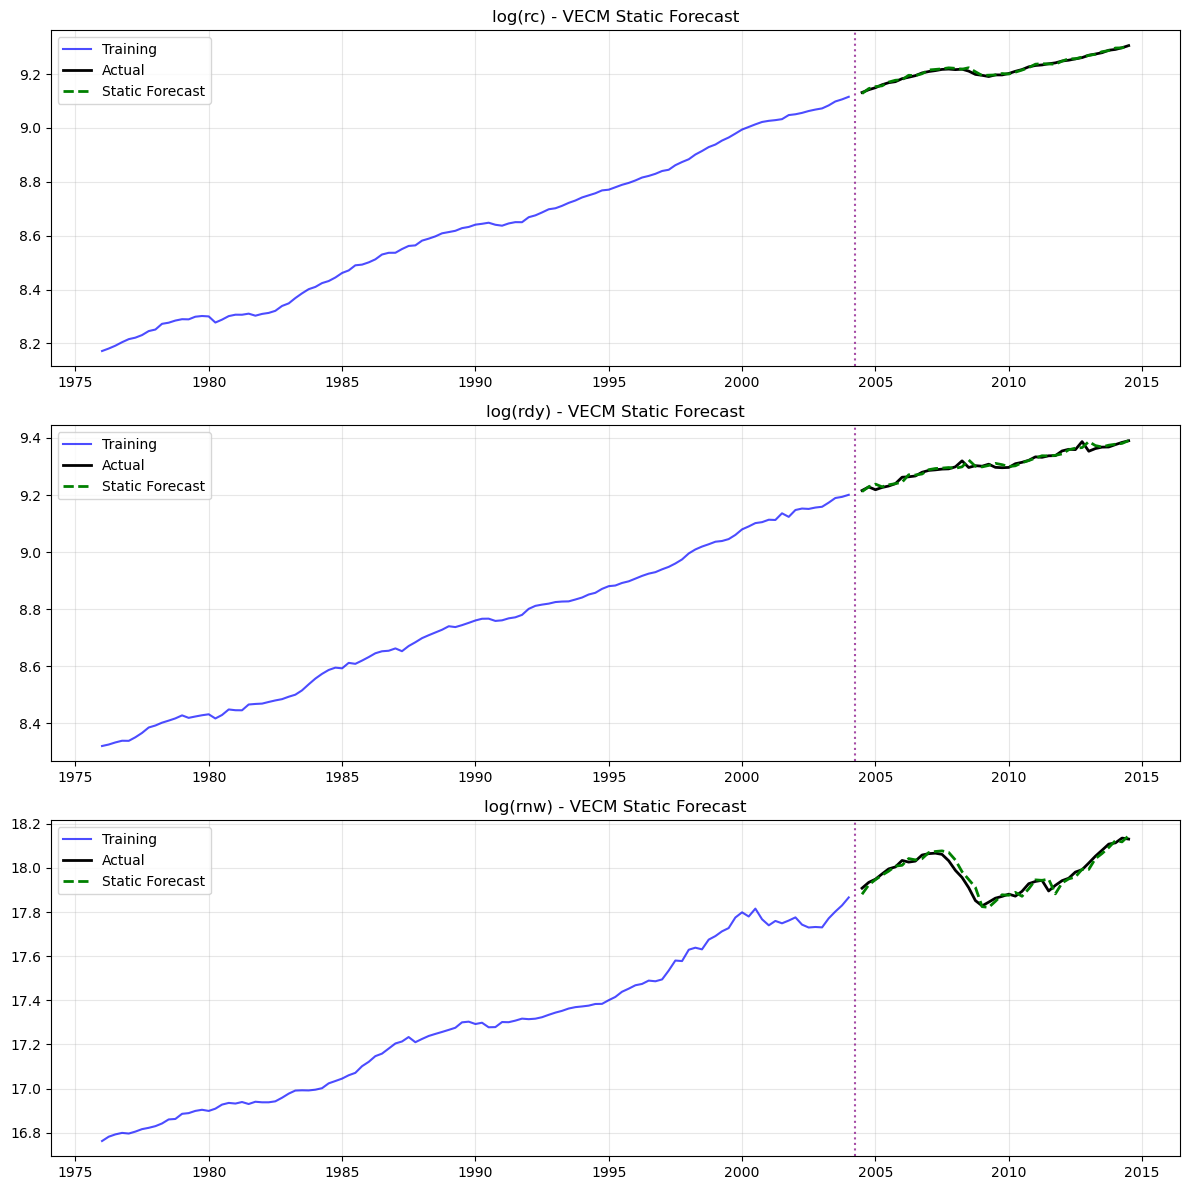

🎉 Done! Check the 'results' dictionary for all outputs.


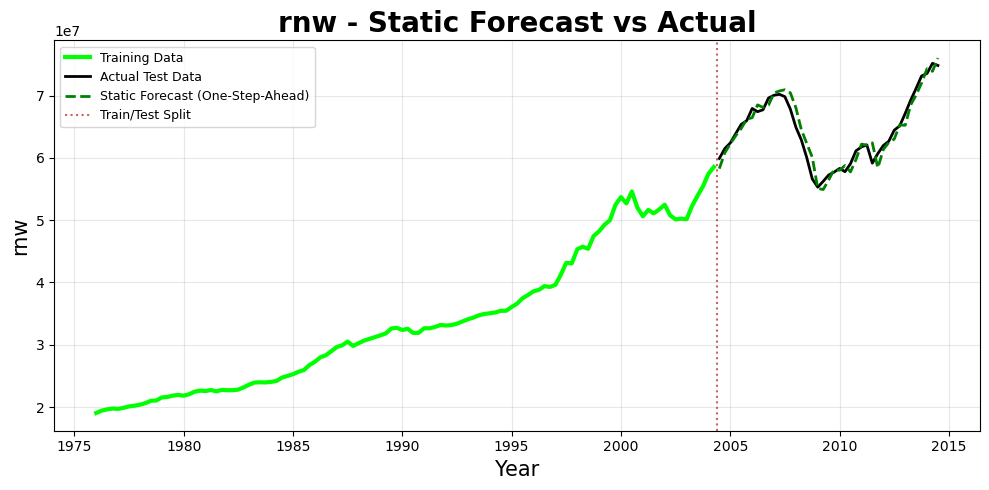

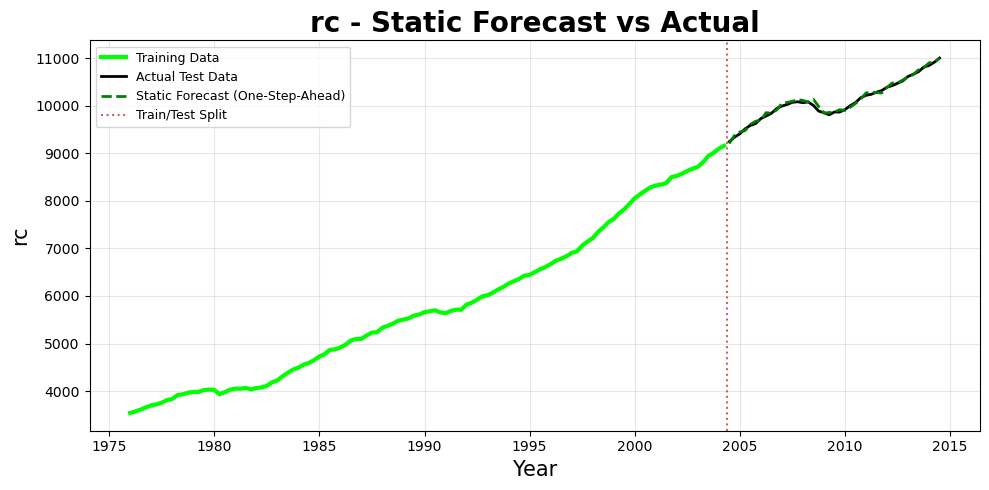

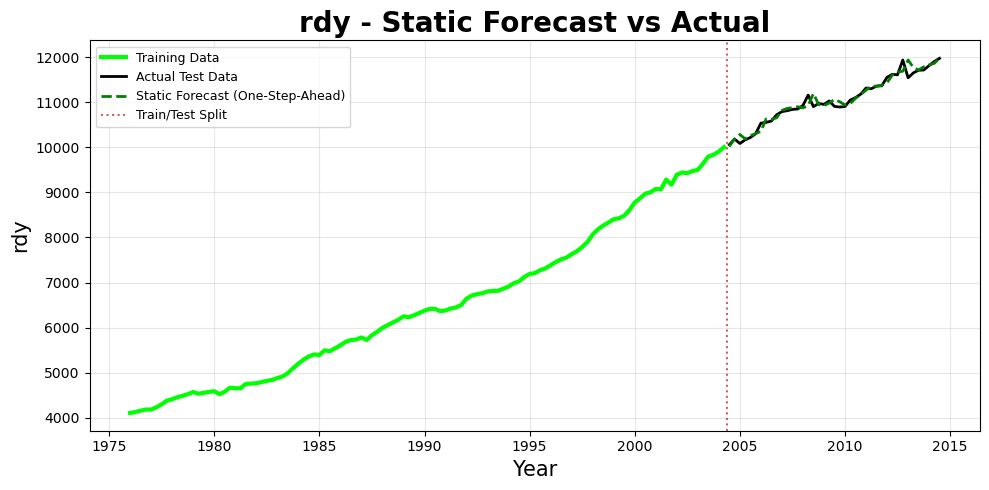

In [55]:
def plot_static_forecast(results, df, variable_name, original_scale=True):
    """
    Plot static (one-step-ahead) forecast vs actual data for VECM results
    
    Parameters:
    - results: Dictionary containing VECM results with 'forecast' and 'actual' keys
    - df: Original dataframe with full time series
    - variable_name: Name of variable to plot (e.g., 'log(rnw)', 'log(rc)', 'log(rdy)')
    - original_scale: If True, convert from log scale to original scale
    """
    
    # Extract data from results dictionary
    forecast_data = results['forecast'][variable_name]
    actual_test_data = results['actual'][variable_name]
    
    # Get training data (everything before the test period)
    train_end_idx = len(df) - len(actual_test_data)
    training_data = df[variable_name][:train_end_idx]
    
    # Convert to original scale if needed
    if original_scale and 'log(' in variable_name:
        forecast_data = np.exp(forecast_data)
        actual_test_data = np.exp(actual_test_data)
        training_data = np.exp(training_data)
        
        # Clean variable name for title
        clean_var_name = variable_name.replace('log(', '').replace(')', '')
        y_label = clean_var_name
        title = f"{clean_var_name} - Static Forecast vs Actual"
    else:
        clean_var_name = variable_name
        y_label = variable_name
        title = f"{variable_name} - Static Forecast vs Actual"
    
    # Create the plot
    plt.figure(figsize=(10, 5))
    
    # Plot training data
    plt.plot(training_data.index, training_data.values, 
             color='lime', linewidth=3.0, label='Training Data')
    
    # Plot actual test data
    plt.plot(actual_test_data.index, actual_test_data.values, 
             color='black', linewidth=2, label='Actual Test Data')
    
    # Plot static forecast
    plt.plot(forecast_data.index, forecast_data.values, 
             color='green', linewidth=2, linestyle='--', label='Static Forecast (One-Step-Ahead)')
    
    # Calculate split date for vertical line
    last_train_date = training_data.index[-1]
    first_forecast_date = forecast_data.index[0]
    split_date = pd.Timestamp(last_train_date) + (pd.Timestamp(first_forecast_date) - pd.Timestamp(last_train_date)) / 2
    
    # Add vertical line at train/test split
    plt.axvline(x=split_date, color='firebrick', linestyle=':', alpha=0.7, label='Train/Test Split')
    
    # Formatting
    plt.title(title, fontsize=20, fontweight='bold')
    plt.xlabel('Year', fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.legend(loc='upper left', fontsize=9)
    plt.grid(True, alpha=0.3)
    
    # Set x-axis to show years 
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

    
results_static = simple_vecm_forecast_static(df_4, train_end_date='2004-03-31')

# Plot individual variables
plot_static_forecast(results_static, df_4, 'log(rnw)', original_scale=True)
plot_static_forecast(results_static, df_4, 'log(rc)', original_scale=True)
plot_static_forecast(results_static, df_4, 'log(rdy)', original_scale=True)

In [56]:
print(df_4)
print(results)

             log(rc)  log(rdy)   log(rnw)  unemployment  consumer_sentiment
dateid01                                                                   
1976-01-01  8.171854  8.320424  16.762529           7.6                84.6
1976-04-01  8.180993  8.325597  16.781955           7.6                83.3
1976-07-01  8.191546  8.332934  16.792481           7.6                89.7
1976-10-01  8.204535  8.338880  16.799313           7.8                87.0
1977-01-01  8.215899  8.338569  16.796359           7.4                87.1
...              ...       ...        ...           ...                 ...
2013-07-01  9.279241  9.367848  18.080066           7.2                77.5
2013-10-01  9.288356  9.368344  18.107855           6.7                82.5
2014-01-01  9.291395  9.376710  18.113577           6.6                80.0
2014-04-01  9.297673  9.384327  18.135219           6.1                84.1
2014-07-01  9.305605  9.390184  18.130669           5.9                86.4

[155 rows x

In [66]:
#Create the forecast savings rate based on the forecast dataframe

forecast_df=results['forecast']
forecast_df['rdy'] = np.exp(forecast_df['log(rdy)'])
forecast_df['rc'] = np.exp(forecast_df['log(rc)'])
forecast_df['rnw']=np.exp(forecast_df['log(rnw)'])











df_5=pd.DataFrame({
    'log(rc)': log_rc_list,
    'log(rdy)': log_rdy_list,
    'log(rnw)': log_rnw_list,
    'unemployment':unemployment,
    'consumer_sentiment':consumer_sentiment,
    'gov_transfers':gov_transfers,
    'y_deflator':y_deflator,
    'interest_payments': interest_payments,   
}, index=filtered_df_1976.index)




rdy=forecast_df['rdy']
rc=forecast_df['rc']
rnw=forecast_df['rnw']
gov_transfers=df_5[df_5.index >= '2004-04-01']['gov_transfers']
interest_payments=df_5[df_5.index >= '2004-04-01']['interest_payments']
y_deflator=df_5[df_5.index >= '2004-04-01']['y_deflator']






# Specify columns to add 
cols_to_add = ['gov_transfers', 'interest_payments', 'y_deflator']  




# Add them to forecast_df
for col in cols_to_add:
    if col in df_5.columns:
        forecast_df[col] = df_5.loc[forecast_df.index, col]

print("Updated forecast_df with specified columns:")


forecast_df['savings_rate_forecasted']=100 * (rdy - (rc + ((gov_transfers + interest_payments)/y_deflator)))/rdy


print(forecast_df)


Updated forecast_df with specified columns:
             log(rc)  log(rdy)   log(rnw)           rdy            rc  \
dateid01                                                                
2004-07-01  9.127561  9.211995  17.880547  10016.556854   9205.540697   
2004-10-01  9.137848  9.221501  17.891691  10112.234027   9300.729220   
2005-01-01  9.147446  9.230396  17.902685  10202.581335   9390.428747   
2005-04-01  9.156899  9.239129  17.913699  10292.065570   9479.610743   
2005-07-01  9.166329  9.247843  17.924748  10382.142320   9569.431149   
2005-10-01  9.175769  9.256563  17.935817  10473.077175   9660.190322   
2006-01-01  9.185222  9.265296  17.946904  10564.941537   9751.940731   
2006-04-01  9.194689  9.274043  17.958008  10657.751914   9844.703845   
2006-07-01  9.204171  9.282803  17.969129  10751.520929   9938.492505   
2006-10-01  9.213667  9.291576  17.980266  10846.259621  10033.319608   
2007-01-01  9.223177  9.300362  17.991421  10941.979331  10129.197984   
2007-04

In [68]:
#Create the actual savings rate based on the actual dataframe from results


actual_df=results['actual']
actual_df['rdy'] = np.exp(actual_df['log(rdy)'])
actual_df['rc'] = np.exp(actual_df['log(rc)'])
actual_df['rnw']=np.exp(actual_df['log(rnw)'])

print(actual_df)





rdy=actual_df['rdy']
rc=actual_df['rc']
rnw=actual_df['rnw']
gov_transfers=df_5['gov_transfers']
interest_payments=df_5['interest_payments']
y_deflator=df_5['y_deflator']


# Specify exactly which columns you want (last 3 from your df_5)
cols_to_add = ['gov_transfers', 'interest_payments', 'y_deflator']  # Adjust based on what you see in df_5

# Add them to forecast_df
for col in cols_to_add:
    if col in df_5.columns:
       actual_df[col] = df_5.loc[forecast_df.index, col]




actual_df['savings_rate_actual']=100 * (rdy - (rc + ((gov_transfers + interest_payments)/y_deflator)))/rdy
print(actual_df)





             log(rc)  log(rdy)   log(rnw)      rdy       rc           rnw  \
dateid01                                                                    
2004-07-01  9.131622  9.215815  17.908219  10054.9   9243.0  5.990190e+07   
2004-10-01  9.141826  9.228239  17.934387  10180.6   9337.8  6.149014e+07   
2005-01-01  9.149443  9.218557  17.948995  10082.5   9409.2  6.239493e+07   
2005-04-01  9.160257  9.226440  17.972527  10162.3   9511.5  6.388067e+07   
2005-07-01  9.167976  9.231564  17.995483  10214.5   9585.2  6.536405e+07   
2005-10-01  9.171735  9.239773  18.004494  10298.7   9621.3  6.595569e+07   
2006-01-01  9.182887  9.262363  18.033882  10534.0   9729.2  6.792279e+07   
2006-04-01  9.188197  9.263862  18.026322  10549.8   9781.0  6.741125e+07   
2006-07-01  9.194018  9.266711  18.030778  10579.9   9838.1  6.771227e+07   
2006-10-01  9.204161  9.279717  18.058329  10718.4   9938.4  6.960376e+07   
2007-01-01  9.209410  9.286255  18.064681  10788.7   9990.7  7.004725e+07   

             log(rc)  log(rdy)   log(rnw)           rdy            rc  \
dateid01                                                                
2004-07-01  9.127561  9.211995  17.880547  10016.556854   9205.540697   
2004-10-01  9.137848  9.221501  17.891691  10112.234027   9300.729220   
2005-01-01  9.147446  9.230396  17.902685  10202.581335   9390.428747   
2005-04-01  9.156899  9.239129  17.913699  10292.065570   9479.610743   
2005-07-01  9.166329  9.247843  17.924748  10382.142320   9569.431149   
2005-10-01  9.175769  9.256563  17.935817  10473.077175   9660.190322   
2006-01-01  9.185222  9.265296  17.946904  10564.941537   9751.940731   
2006-04-01  9.194689  9.274043  17.958008  10657.751914   9844.703845   
2006-07-01  9.204171  9.282803  17.969129  10751.520929   9938.492505   
2006-10-01  9.213667  9.291576  17.980266  10846.259621  10033.319608   
2007-01-01  9.223177  9.300362  17.991421  10941.979331  10129.197984   
2007-04-01  9.232703  9.309162  18.002593  11038.69

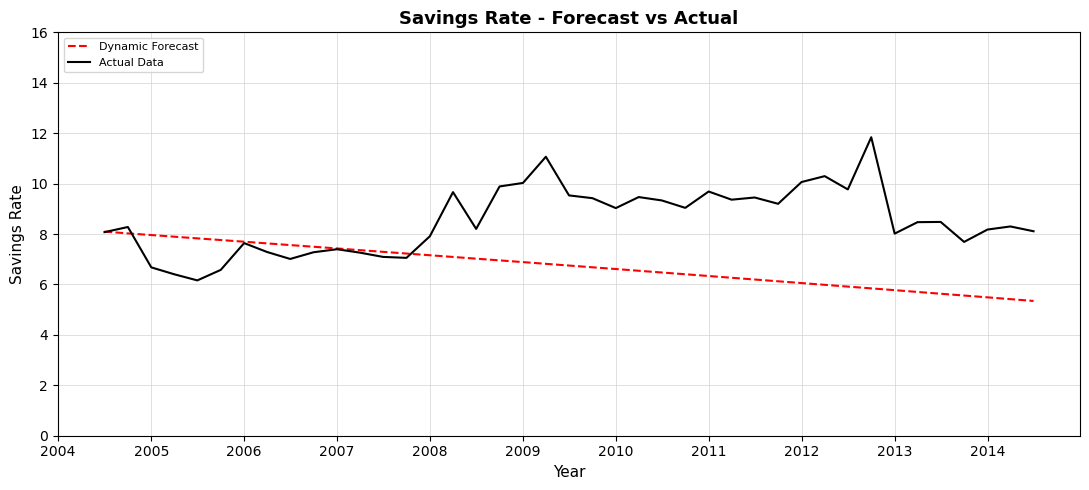

In [77]:



print(forecast_df)


#Add savings rate to forecast dataframe
forecast_df['savings_rate_forecast'] = 100 * (forecast_df['rdy'] - forecast_df['rc']) / forecast_df['rdy']

#Add savings rate to actual dataframe
actual_df['savings_rate_actual'] = 100 * (actual_df['rdy'] - actual_df['rc']) / actual_df['rdy']


#Plot the saivngs rate preduction against the acutal
fig, ax = plt.subplots(figsize=(11, 5))

# Plot forecasted (red dashed)
ax.plot(forecast_df.index, forecast_df['savings_rate_forecasted'],
        color='red', linewidth=1.5, linestyle='--', label='Dynamic Forecast')

# Plot actual (black solid)
ax.plot(actual_df.index, actual_df['savings_rate_actual'],
        color='black', linewidth=1.5, label='Actual Data')

# Styling
ax.set_ylim(0, 16)
ax.set_title('Savings Rate - Forecast vs Actual', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Savings Rate', fontsize=11)
ax.grid(True, color='lightgray', linewidth=0.5)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [81]:
#Create the forecast savings rate based on the forecast dataframe

forecast_df=results['savings_rate_forecasted']
forecast_df['rdy'] = np.exp(forecast_df['log(rdy)'])
forecast_df['rc'] = np.exp(forecast_df['log(rc)'])
forecast_df['rnw']=np.exp(forecast_df['log(rnw)'])



df_5=pd.DataFrame({
    'log(rc)': log_rc_list,
    'log(rdy)': log_rdy_list,
    'log(rnw)': log_rnw_list,
    'unemployment':unemployment,
    'consumer_sentiment':consumer_sentiment,
    'gov_transfers':gov_transfers,
    'y_deflator':y_deflator,
    'interest_payments': interest_payments,   
}, index=filtered_df_1976.index)




rdy=forecast_df['rdy']
rc=forecast_df['rc']
rnw=forecast_df['rnw']
gov_transfers=df_5[df_5.index >= '2004-04-01']['gov_transfers']
interest_payments=df_5[df_5.index >= '2004-04-01']['interest_payments']
y_deflator=df_5[df_5.index >= '2004-04-01']['y_deflator']






# Specify columns to add 
cols_to_add = ['gov_transfers', 'interest_payments', 'y_deflator']  




# Add them to forecast_df
for col in cols_to_add:
    if col in df_5.columns:
        forecast_df[col] = df_5.loc[forecast_df.index, col]

print("Updated forecast_df with specified columns:")


forecast_df['savings_rate_forecasted']=100 * (rdy - (rc + ((gov_transfers + interest_payments)/y_deflator)))/rdy


print(forecast_df)


KeyError: 'savings_rate_forecasted'

In [79]:
#Create the actual savings rate based on the actual dataframe from results


actual_df=results['actual']
actual_df['rdy'] = np.exp(actual_df['log(rdy)'])
actual_df['rc'] = np.exp(actual_df['log(rc)'])
actual_df['rnw']=np.exp(actual_df['log(rnw)'])

print(actual_df)





rdy=actual_df['rdy']
rc=actual_df['rc']
rnw=actual_df['rnw']
gov_transfers=df_5['gov_transfers']
interest_payments=df_5['interest_payments']
y_deflator=df_5['y_deflator']


# Specify exactly which columns you want (last 3 from your df_5)
cols_to_add = ['gov_transfers', 'interest_payments', 'y_deflator']  # Adjust based on what you see in df_5

# Add them to forecast_df
for col in cols_to_add:
    if col in df_5.columns:
       actual_df[col] = df_5.loc[forecast_df.index, col]




actual_df['savings_rate_actual']=100 * (rdy - (rc + ((gov_transfers + interest_payments)/y_deflator)))/rdy
print(actual_df)





             log(rc)  log(rdy)   log(rnw)      rdy       rc           rnw  \
dateid01                                                                    
2004-07-01  9.131622  9.215815  17.908219  10054.9   9243.0  5.990190e+07   
2004-10-01  9.141826  9.228239  17.934387  10180.6   9337.8  6.149014e+07   
2005-01-01  9.149443  9.218557  17.948995  10082.5   9409.2  6.239493e+07   
2005-04-01  9.160257  9.226440  17.972527  10162.3   9511.5  6.388067e+07   
2005-07-01  9.167976  9.231564  17.995483  10214.5   9585.2  6.536405e+07   
2005-10-01  9.171735  9.239773  18.004494  10298.7   9621.3  6.595569e+07   
2006-01-01  9.182887  9.262363  18.033882  10534.0   9729.2  6.792279e+07   
2006-04-01  9.188197  9.263862  18.026322  10549.8   9781.0  6.741125e+07   
2006-07-01  9.194018  9.266711  18.030778  10579.9   9838.1  6.771227e+07   
2006-10-01  9.204161  9.279717  18.058329  10718.4   9938.4  6.960376e+07   
2007-01-01  9.209410  9.286255  18.064681  10788.7   9990.7  7.004725e+07   

             log(rc)  log(rdy)   log(rnw)           rdy            rc  \
dateid01                                                                
2004-07-01  9.127561  9.211995  17.880547  10016.556854   9205.540697   
2004-10-01  9.137848  9.221501  17.891691  10112.234027   9300.729220   
2005-01-01  9.147446  9.230396  17.902685  10202.581335   9390.428747   
2005-04-01  9.156899  9.239129  17.913699  10292.065570   9479.610743   
2005-07-01  9.166329  9.247843  17.924748  10382.142320   9569.431149   
2005-10-01  9.175769  9.256563  17.935817  10473.077175   9660.190322   
2006-01-01  9.185222  9.265296  17.946904  10564.941537   9751.940731   
2006-04-01  9.194689  9.274043  17.958008  10657.751914   9844.703845   
2006-07-01  9.204171  9.282803  17.969129  10751.520929   9938.492505   
2006-10-01  9.213667  9.291576  17.980266  10846.259621  10033.319608   
2007-01-01  9.223177  9.300362  17.991421  10941.979331  10129.197984   
2007-04-01  9.232703  9.309162  18.002593  11038.69

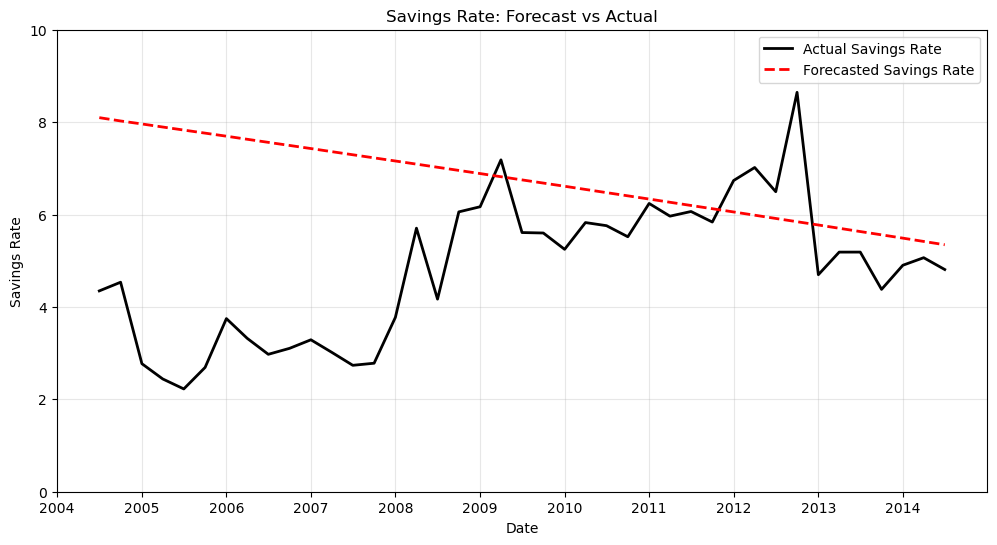

In [80]:
actual_df=results['actual']
forecast_df=results['forecast']



print(forecast_df)
savings_rate_forecast = forecast_df['savings_rate_forecast']
savings_rate_actual = actual_df['savings_rate_actual']

# Print both series
print("Forecasted Savings Rate:")
print(savings_rate_forecast)
print("\nActual Savings Rate:")
print(savings_rate_actual)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Forecasted': savings_rate_forecast,
    'Actual': savings_rate_actual
})

print("\nSide-by-side Comparison:")
print(comparison_df)

# Calculate the difference
comparison_df['Difference'] = comparison_df['Actual'] - comparison_df['Forecasted']
comparison_df['Abs_Difference'] = abs(comparison_df['Difference'])

print("\nWith Differences:")
print(comparison_df)

# Calculate some basic metrics
print(f"\nComparison Metrics:")
print(f"Mean Absolute Error: {comparison_df['Abs_Difference'].mean():.6f}")
print(f"Root Mean Square Error: {np.sqrt((comparison_df['Difference']**2).mean()):.6f}")
print(f"Mean Difference: {comparison_df['Difference'].mean():.6f}")

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Actual'], 
         label='Actual Savings Rate', color='black', linewidth=2)
plt.plot(comparison_df.index, comparison_df['Forecasted'], 
         label='Forecasted Savings Rate', color='red', linestyle='--', linewidth=2)
plt.ylim(0, 10)
plt.title('Savings Rate: Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Savings Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


